<a href="https://colab.research.google.com/github/isa-ulisboa/greends-pml/blob/main/notebooks/assign_1_wine_quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ucimlrepo

# Get data from https://archive.ics.uci.edu/dataset/186/wine+quality

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
wine_quality = fetch_ucirepo(id=186)

# data (as pandas dataframes)
X = wine_quality.data.features
y = wine_quality.data.targets

# metadata
print(wine_quality.metadata)

# variable information
print(wine_quality.variables)


{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine preferences

# Define Linear Regression class

In [ ]:
import numpy as np

class LinearRegressionFromScratch:
    """
    A Linear Regression model implemented from scratch.
    This class allows for discussion of the following machine learning concepts:
    input, output, model, loss function, epoch, batch, predict, train dataset, and test dataset.
    """

    def __init__(self, learning_rate=0.01, n_epochs=100):
        """
        Initializes the Linear Regression model.

        Arguments:
            learning_rate (float): The step size taken during gradient descent. (Discusses 'model' parameter tuning)
            n_epochs (int): The number of times to iterate over the entire training dataset. (Discusses 'epoch')
        """
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.weights = None  # The coefficients of the linear model
        self.bias = None     # The intercept of the linear model
        self.losses = []     # To store the loss at each epoch

    def fit(self, X_train, y_train):
        """
        Trains the Linear Regression model using gradient descent.

        Arguments:
            X_train (np.array): The training input features. (Discusses 'input' and 'train dataset')
            y_train (np.array): The training output/target values. (Discusses 'output' and 'train dataset')
        """
        n_samples, n_features = X_train.shape

        # 1. Initialize the Model (weights and bias)
        # The 'model' is defined by these parameters (weights and bias)
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Gradient Descent Loop
        for epoch in range(self.n_epochs):  # (Discusses 'epoch')
            # For simplicity, we'll use full batch gradient descent here.
            # A 'batch' in this context is the entire training dataset.
            # For mini-batch gradient descent, we would process smaller subsets of X_train/y_train.

            # Make predictions with current model parameters
            # This is the 'model's current output for the given 'input' (X_train)
            y_predicted = np.dot(X_train, self.weights) + self.bias

            # 2. Calculate the Loss Function (Mean Squared Error)
            # The 'loss function' measures how well the model's predictions match the actual 'output' (y_train).
            loss = np.mean((y_predicted - y_train)**2)
            self.losses.append(loss)

            # Calculate gradients
            # These tell us how much to adjust weights and bias to reduce the loss
            dw = (1/n_samples) * np.dot(X_train.T, (y_predicted - y_train))
            db = (1/n_samples) * np.sum(y_predicted - y_train)

            # Update Model Parameters (weights and bias)
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # Optional: Print loss to observe learning progress
            # if (epoch+1) % 100 == 0:
            #     print(f'Epoch [{epoch+1}/{self.n_epochs}], Loss: {loss:.4f}')

        print(f"Training finished. Final Loss: {self.losses[-1]:.4f}")

    def predict(self, X_test):
        """
        Makes predictions using the trained Linear Regression model.

        Arguments:
            X_test (np.array): The independent test input features. (Discusses 'independent test dataset')

        Returns:
            np.array: Predicted output values. (Discusses 'predict' and 'output')
        """
        # The 'predict' step uses the learned 'model' to generate new 'output' for unseen 'input'.
        y_predicted = np.dot(X_test, self.weights) + self.bias
        return y_predicted

# Example Usage and Discussion Points:
# 1. Input and Output: X (features) are 'input', y (target) is 'output'.
# 2. Model: The LinearRegressionFromScratch class itself, with its weights and bias, represents the 'model'.
# 3. Loss Function: Mean Squared Error (MSE) is used in the 'fit' method to quantify prediction error.
# 4. Epoch: The 'n_epochs' parameter and the loop in 'fit' demonstrate this.
# 5. Batch: In this implementation, the entire training data is treated as one 'batch' for full batch gradient descent.
#    You can explain how mini-batches would involve splitting X_train/y_train into smaller chunks.
# 6. Predict: The 'predict' method generates new outputs based on new inputs.
# 7. Train Dataset: X_train and y_train are used to train the model.
# 8. Independent Test Dataset: X_test is used to evaluate the model's performance on unseen data after training.

# Instantiate and train the model
# Assuming X_train, y_train, X_test are already available from previous cells
# model = LinearRegressionFromScratch(learning_rate=0.01, n_epochs=1000)
# model.fit(X_train, y_train)

# Make predictions on the test set
# y_pred = model.predict(X_test)

# Evaluate the model (e.g., using Mean Squared Error on test set)
# from sklearn.metrics import mean_squared_error
# mse_test = mean_squared_error(y_test, y_pred)
# print(f"Test MSE: {mse_test:.4f}")

# Divide data set in train and test; Scale predictors (optional)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Convert y DataFrame to a 1D numpy array if it's a single column
y_np = y.values.ravel() if y.shape[1] == 1 else y.values
X_np = X.values # Convert X DataFrame to numpy array

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_np, y_np, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled, y_train, X_test_scaled, y_test have been created.")

X_train_scaled, y_train, X_test_scaled, y_test have been created.


# Fit model; Predict y for X_test; Calculate MSE on test set

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Instantiate and train the model
# Assuming X_train_scaled, y_train, X_test_scaled, y_test are already available
model = LinearRegressionFromScratch(learning_rate=0.01, n_epochs=100)
model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# Calculate MSE on test set
mse_test = mean_squared_error(y_test, y_pred)
print(f"Test MSE: {mse_test:.4f}")

Training finished. Final Loss: 5.2005
Test MSE: 5.1992


# Create plots

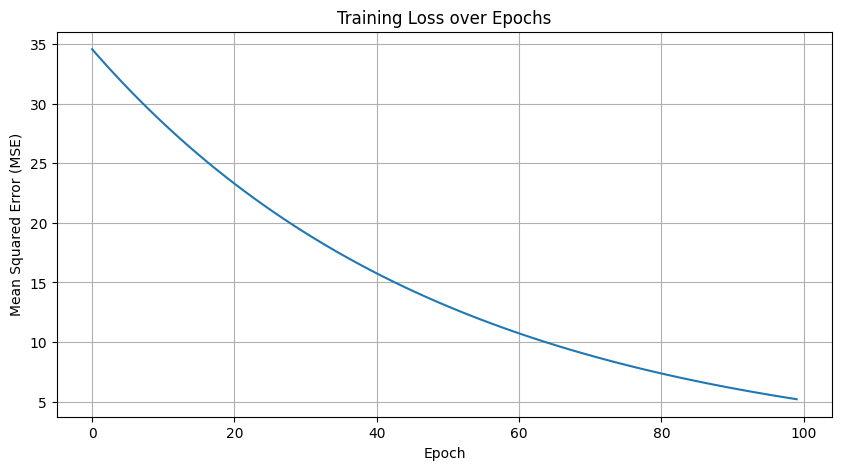

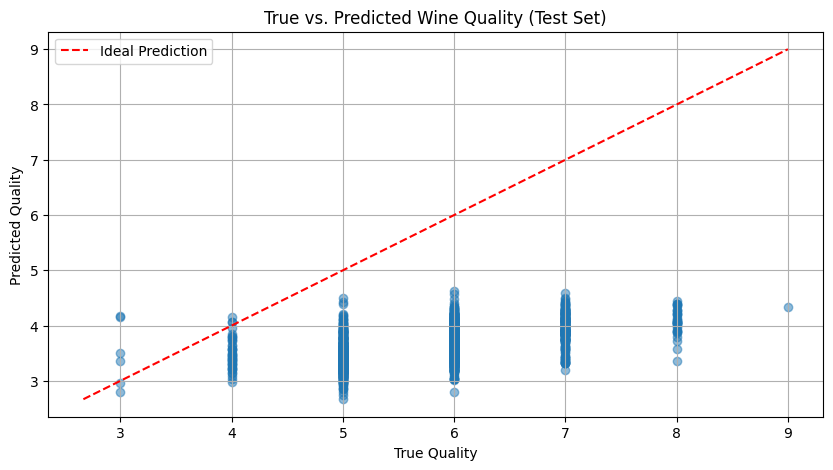

In [ ]:
# 1. Plot of Loss vs. Epoch
plt.figure(figsize=(10, 5))
plt.plot(range(len(model.losses)), model.losses)
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True)
plt.show()

# 2. Scatter plot of True vs. Predicted values for the test set
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.5)
# Add a diagonal line for perfect predictions
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal Prediction')
plt.title('True vs. Predicted Wine Quality (Test Set)')
plt.xlabel('True Quality')
plt.ylabel('Predicted Quality')
plt.grid(True)
plt.legend()
plt.show()